In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

import matplotlib.lines as mlines
from sklearn.cluster import KMeans
from collections import Counter

from scipy.stats import chi2_contingency

In [34]:
# Dataframe laden und vorbereiten
regions = ['CDR_H1', 'CDR_H2', 'CDR_H3', 'CDR_L1', 'CDR_L2', 'CDR_L3']
ab_ag_annotated = (
    pd.read_csv("data/ab_ag_annotated.tsv", sep="\t", usecols=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["resolution"] + regions)
    .dropna(subset= regions)
    .drop_duplicates(subset = ["pdb"] + regions, keep="first")
    .reset_index(drop=True)
)

ab_ag_annotated = ab_ag_annotated[ab_ag_annotated['resolution'] <= 3.5]

#####liste mit den top antigen_names erstellen
top_antigens = ab_ag_annotated['antigen_name'].value_counts().head(10).index.tolist()
#dataframe filtern sodass nur top 10 antigene drin bleiben
ab_ag_annotated_top = ab_ag_annotated[ab_ag_annotated['antigen_name'].isin(top_antigens)].copy()
#antigen labels definieren sodass nur top 10
antigen_labels = ab_ag_annotated_top["antigen_name"].tolist() #entspricht der spalte "antigen_name" aus ab_ag_annotated_top (aber mit neuen indices!)

#überprüfung was die top 10 sind
print("Top 10 Antigene:")
for ant in top_antigens:
    print(f"-{ant}")

# Liste mit allen proteinogenen Aminosäuren (wird später für die PCA benötigt)
residues = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]

# Liste aller CDR-Regionen
regions = ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]

Top 10 Antigene:
-spike glycoprotein
-spike protein s1
-guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 
-hemagglutinin
-envelope glycoprotein gp160
-envelope glycoprotein gp120
-neuraminidase
-surface glycoprotein
-hemagglutinin | hemagglutinin
-fusion glycoprotein f0


In [35]:
#PCA nur für AK mit antigen name in den top 10 (pca für alle ist zu finden in annasworksheet)

def residue_percentage(sequence, residues):
    """
    Berechnet den prozentualen Anteil jeder Aminosäure in der gegebenen Sequenz und gibt eine Liste seq_residues zurück,
    die jede Aminosäure als Tupel (residue, percentage) enthält.
    sequence: list, die eine CDR-Sequenz repäsentiert, und deren Einträge aus einem String pro Aminosäure besteht, z.B. ['A', 'R', 'N', ...]
    """
    seq_residues = []
    for residue in residues:
        percentage = sequence.count(residue) / len(sequence)
        seq_residues.append((residue, percentage))
    return seq_residues


def show_feature_space(feature_space, CDR_region, antigen_labels):#zusätzliches Argument für color-coding: antigen
    """
    Visualisiert den Feature-Space der CDR-Sequenzen mittels PCA in 3D.
    feature_space: pd.DataFrame, der die PDB-IDs in einer Spalte "pdb" und die prozentualen Anteile der Aminosäuren in den entsprechenden CDR-Sequenzen
    in je einer Spalte pro Aminosäure enthält.
    """
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)
    #hier nochmal die top 10 damit unique antigens auch wirklich nur die top 10 nimmt 
    #####liste mit den top antigen_names erstellen
    top_antigens = ab_ag_annotated['antigen_name'].value_counts().head(10).index.tolist()
    #dataframe filtern sodass nur top 10 antigene drin bleiben
    ab_ag_annotated_top = ab_ag_annotated[ab_ag_annotated['antigen_name'].isin(top_antigens)].copy()
    #antigen labels definieren sodass nur top 10
    antigen_labels = ab_ag_annotated_top["antigen_name"].tolist()

    #### Farbzuordnung vorbereiten

    unique_antigens = sorted(list(set(antigen_labels)))
    color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
    color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
    colors = [color_dict[a] for a in antigen_labels]
   

    # Plotten der PCA-Koordinaten in 3D
    fig, (ax_scatter, ax_legend) = plt.subplots(2,1,figsize=(10,10), gridspec_kw={'height_ratios': [4,1]})
    ax_scatter.scatter(coords[:, 0], coords[:, 1], c=colors, s=20, alpha=0.7)#zusätzliche Argumente für color-coding: c=color_codes, cmap='tab20', 
    ax_scatter.set_xlabel("PCA 1")
    ax_scatter.set_ylabel("PCA 2")
    ax_scatter.set_title(f"PCA of {CDR_region} Sequences")


    # 2. Legende als eigene Figure
    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Größe anpassen je nach Anzahl Antigene
    legend_ax.axis('off')  # Keine Achsen

    # Erstelle Handles
    handles = [mlines.Line2D([], [], color=color_dict[ant], marker='o', linestyle='None',
                             markersize=8, label=ant)
               for ant in unique_antigens]

    # Erzeuge Legende
    legend = legend_ax.legend(handles=handles, loc='center', ncol=1, fontsize='small')  # ncol=1 → alle untereinander

    legend_fig.tight_layout()
    plt.show()

In [44]:
'''Kann der Teil in die Funktion show_feature_space eingebaut werden?'''
unique_antigens = sorted(list(set(antigen_labels)))
color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
colors = [color_dict[a] for a in antigen_labels]

# Dictionary, das die Feature-Space DataFrames für jede CDR-Region speichert
feature_spaces = {}
# Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen und zu visualisieren:
for region in regions: 
    # Berechne den prozentualen Anteil jeder Aminosäure in den CDR-Sequenzen und füge sie in den Feature-Space ein.
    fs_rows = [] #um daten vor befüllen des dataframes vorzubereiten damit es nicht so lange dauert
    for i, ab_ag_annotated_top_row in ab_ag_annotated_top.iterrows():
        pdb = ab_ag_annotated_top_row['pdb']
        antigen_name = ab_ag_annotated_top_row['antigen_name']
        antigen_species = ab_ag_annotated_top_row['antigen_species']
        seq_as_str = ab_ag_annotated_top_row[region]
        seq_as_list = list(seq_as_str)

        residues_percentages = residue_percentage(seq_as_list, residues)
        percentages = [pair[1] for pair in residues_percentages]

        seq_length = len(seq_as_list)

        fs_row = [pdb] + [antigen_name] + [antigen_species] + [seq_length] + percentages
        fs_rows.append(fs_row)

    feature_space = pd.DataFrame(fs_rows_z, columns=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["seq_length"] + residues)
    columns_to_scale = ["seq_length"] + residues
    feature_space_z = feature_space.copy()
    feature_space_z[columns_to_scale] = (feature_space[columns_to_scale] - np.mean(feature_space[columns_to_scale], axis=0)) / np.std(feature_space[columns_to_scale], axis=0)
    feature_spaces[region] = feature_space_z


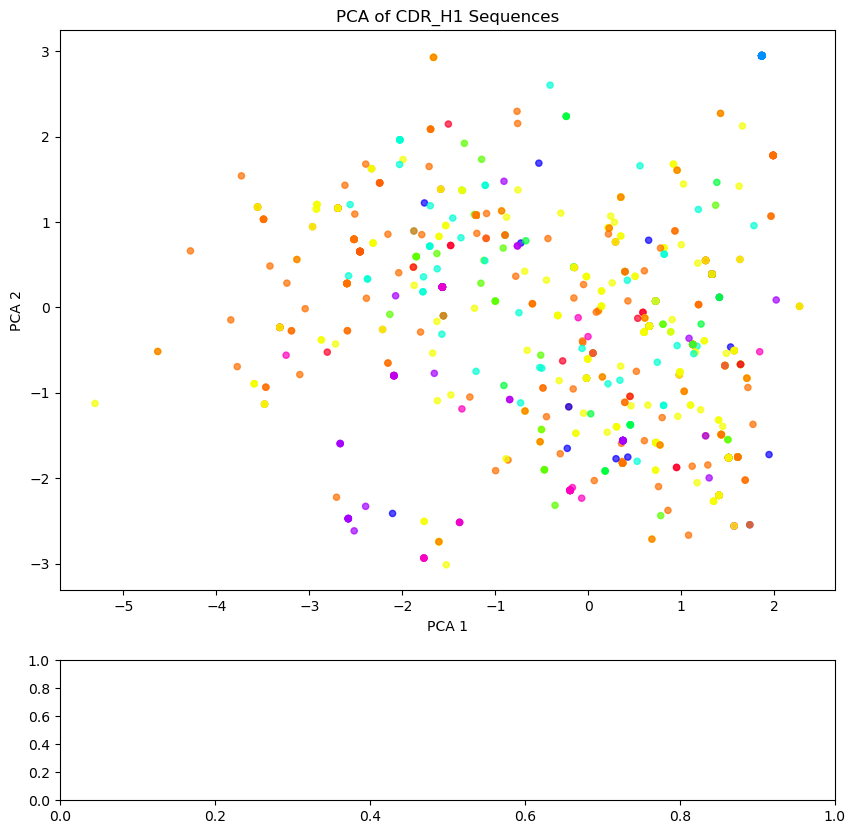

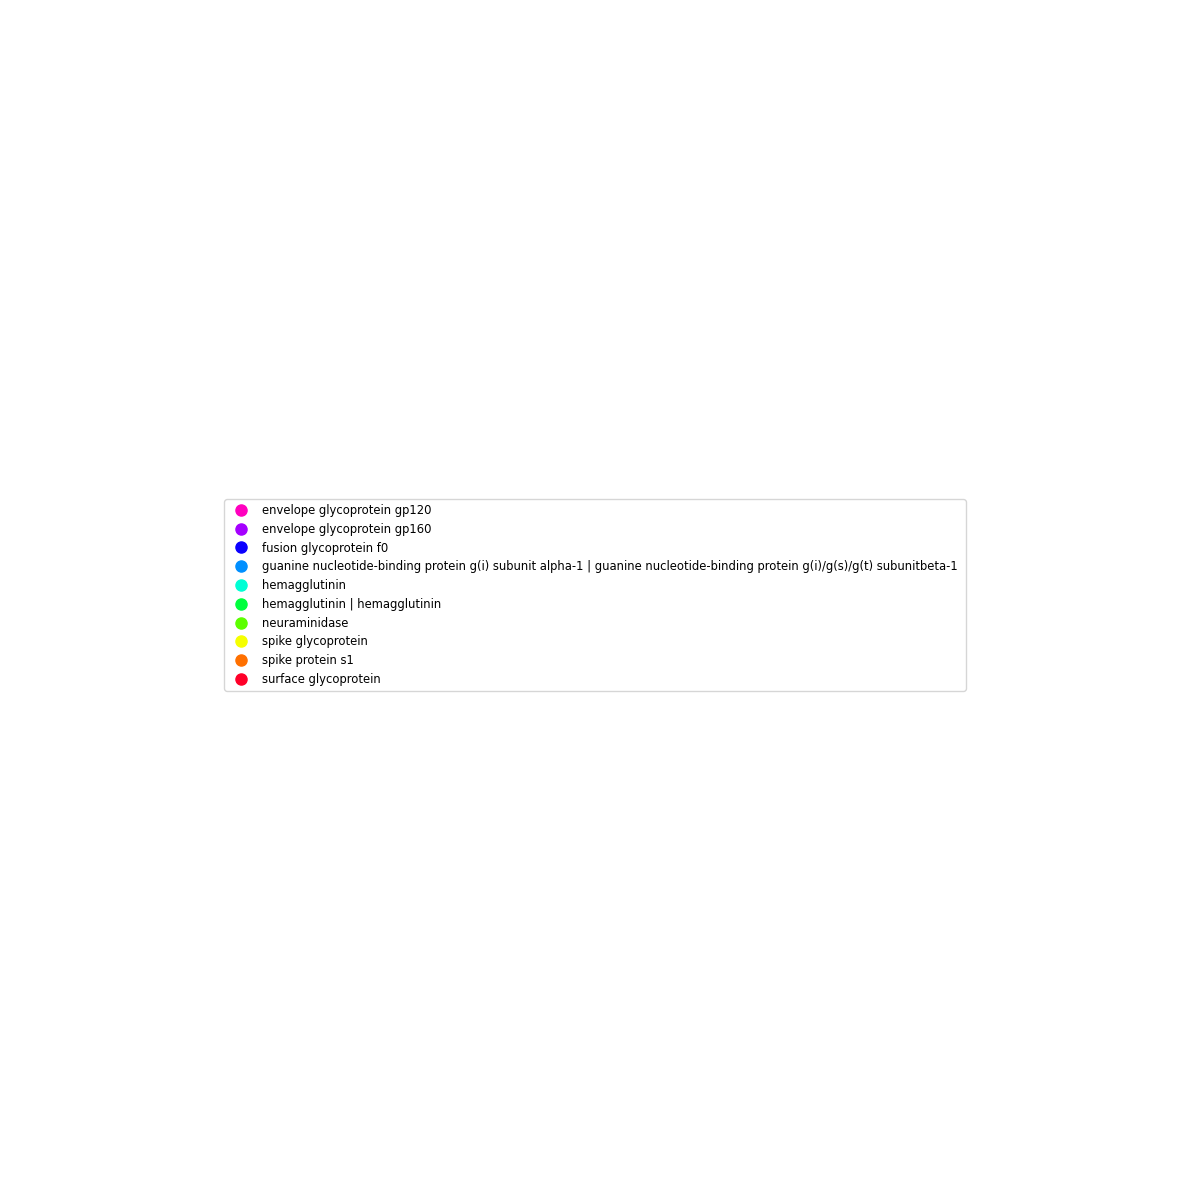

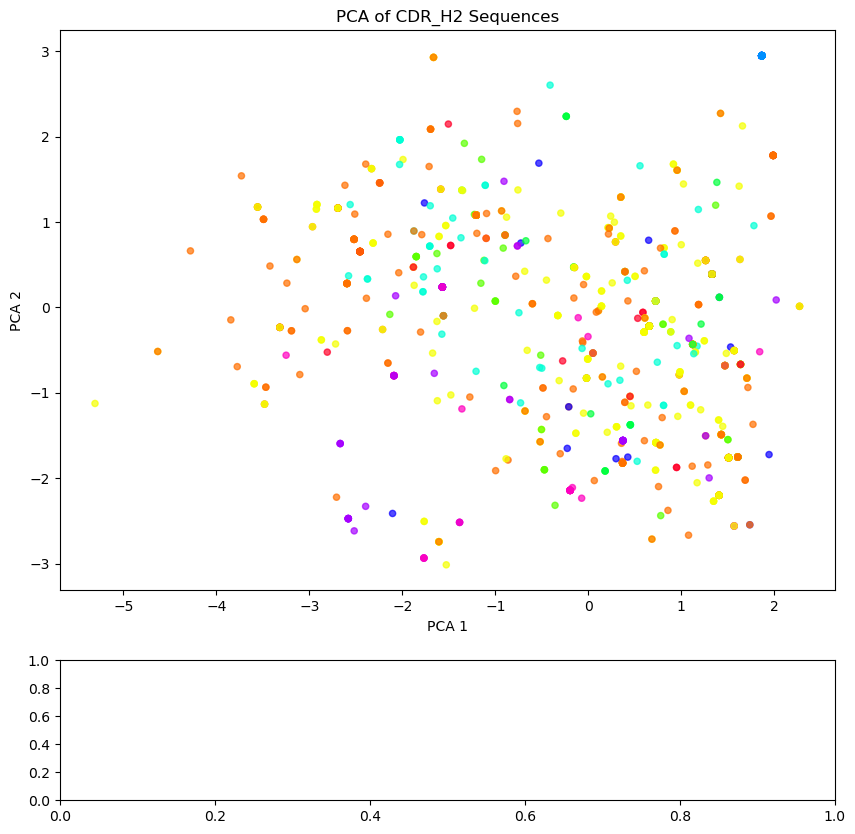

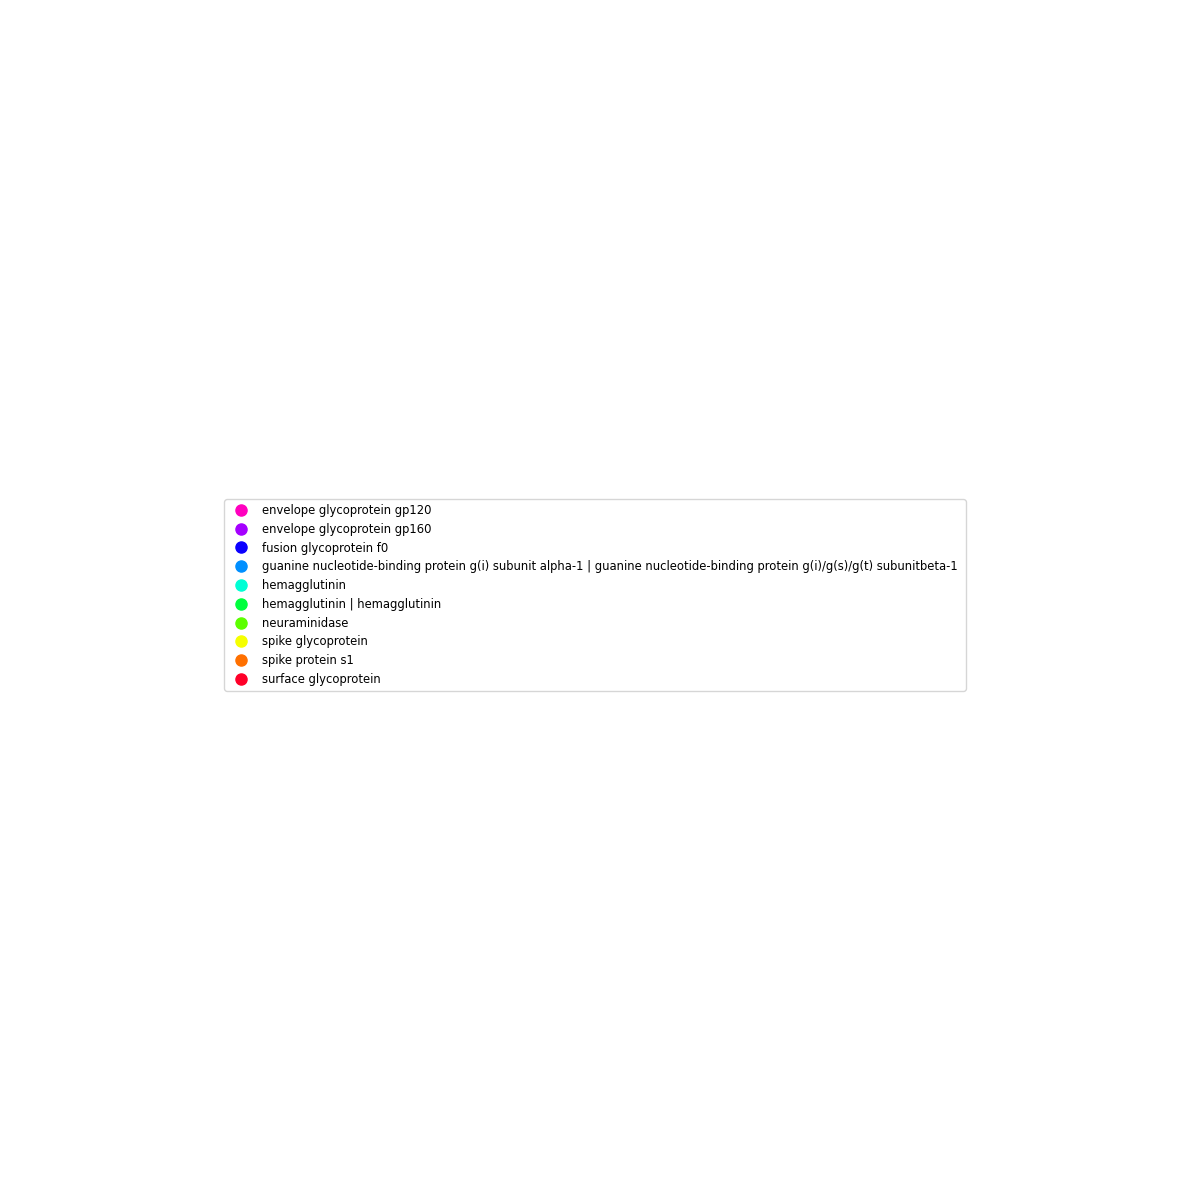

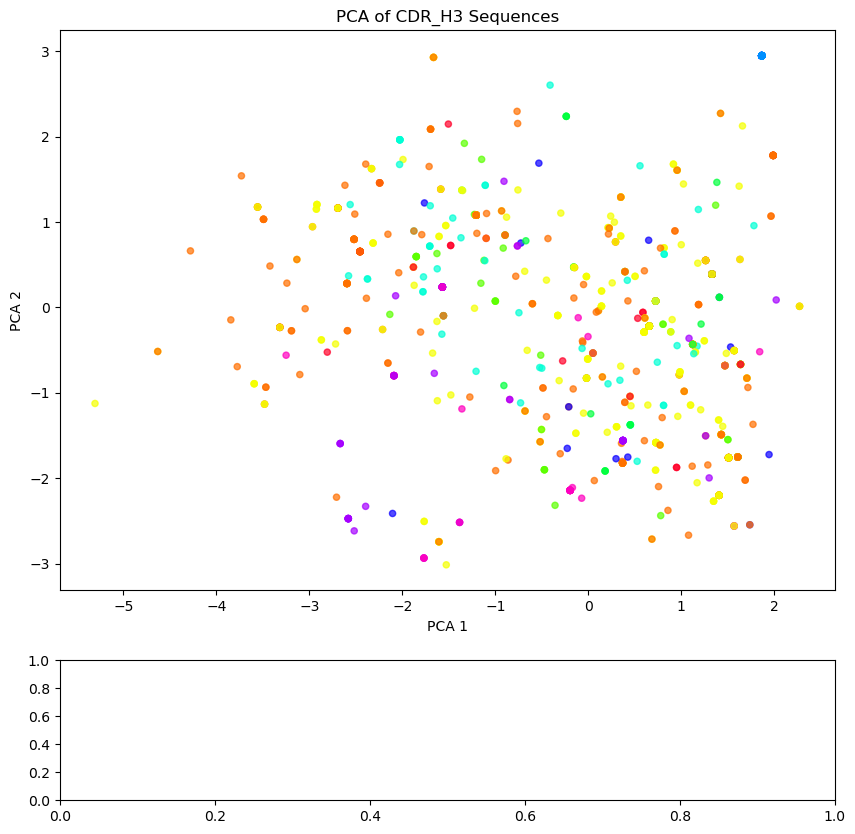

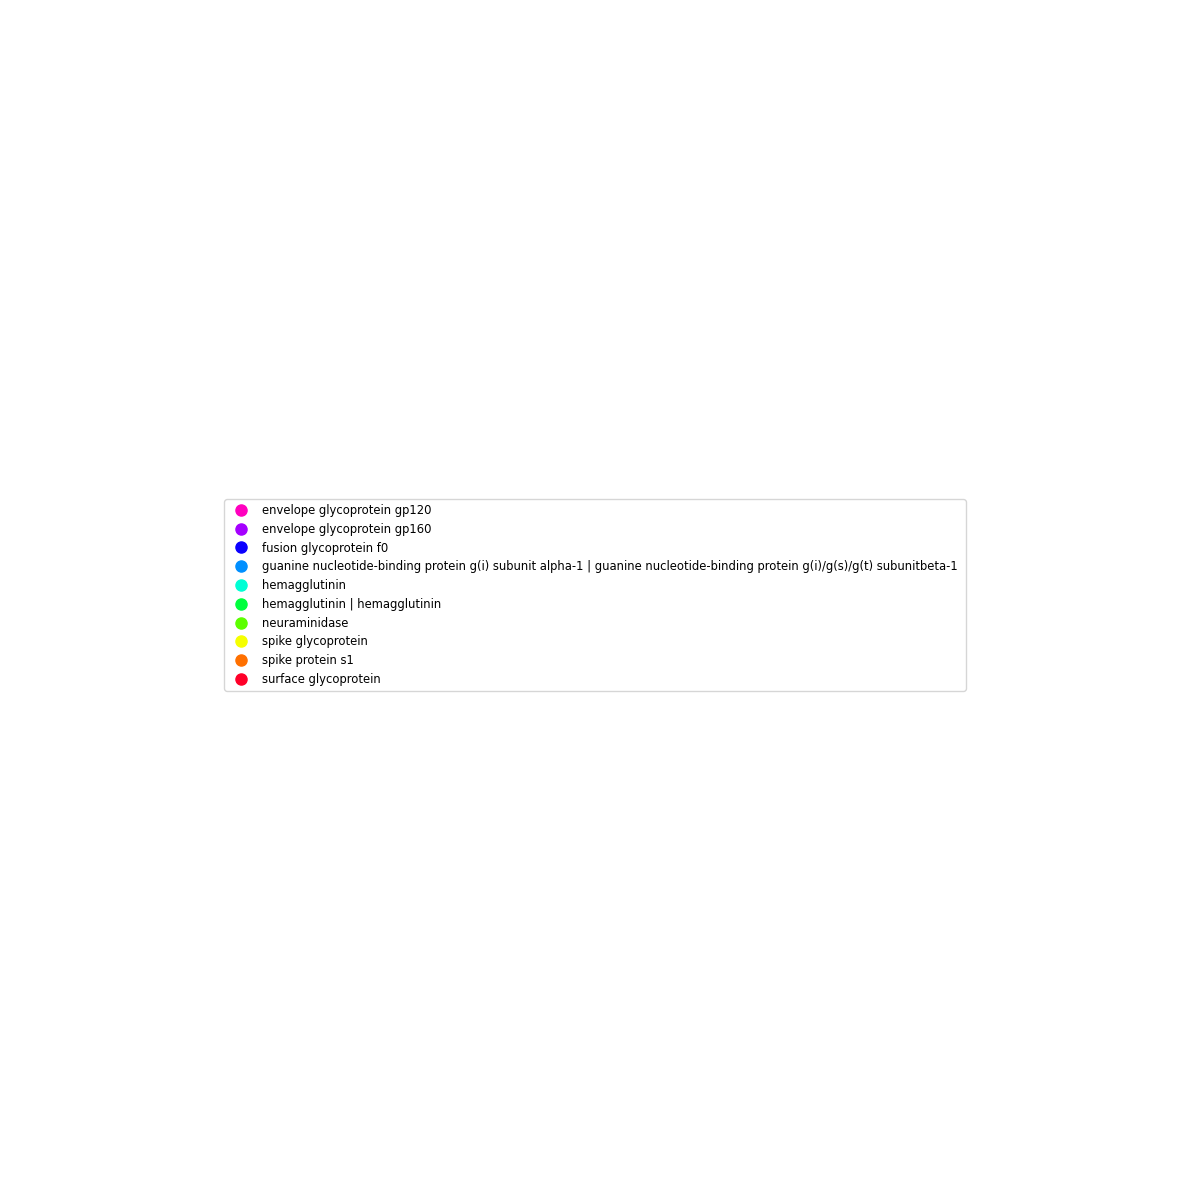

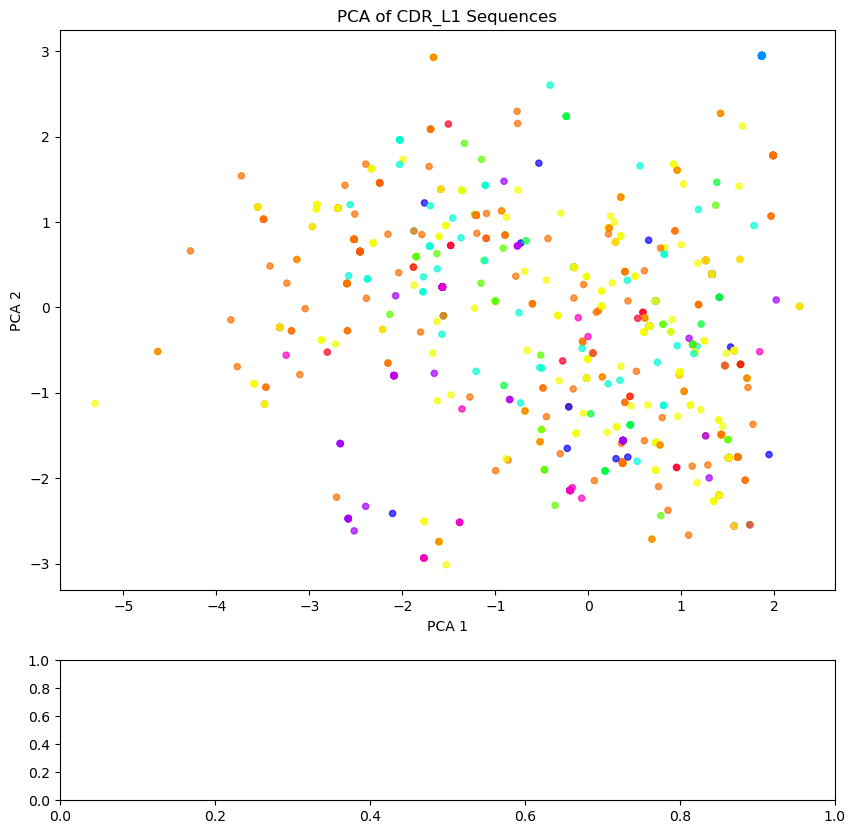

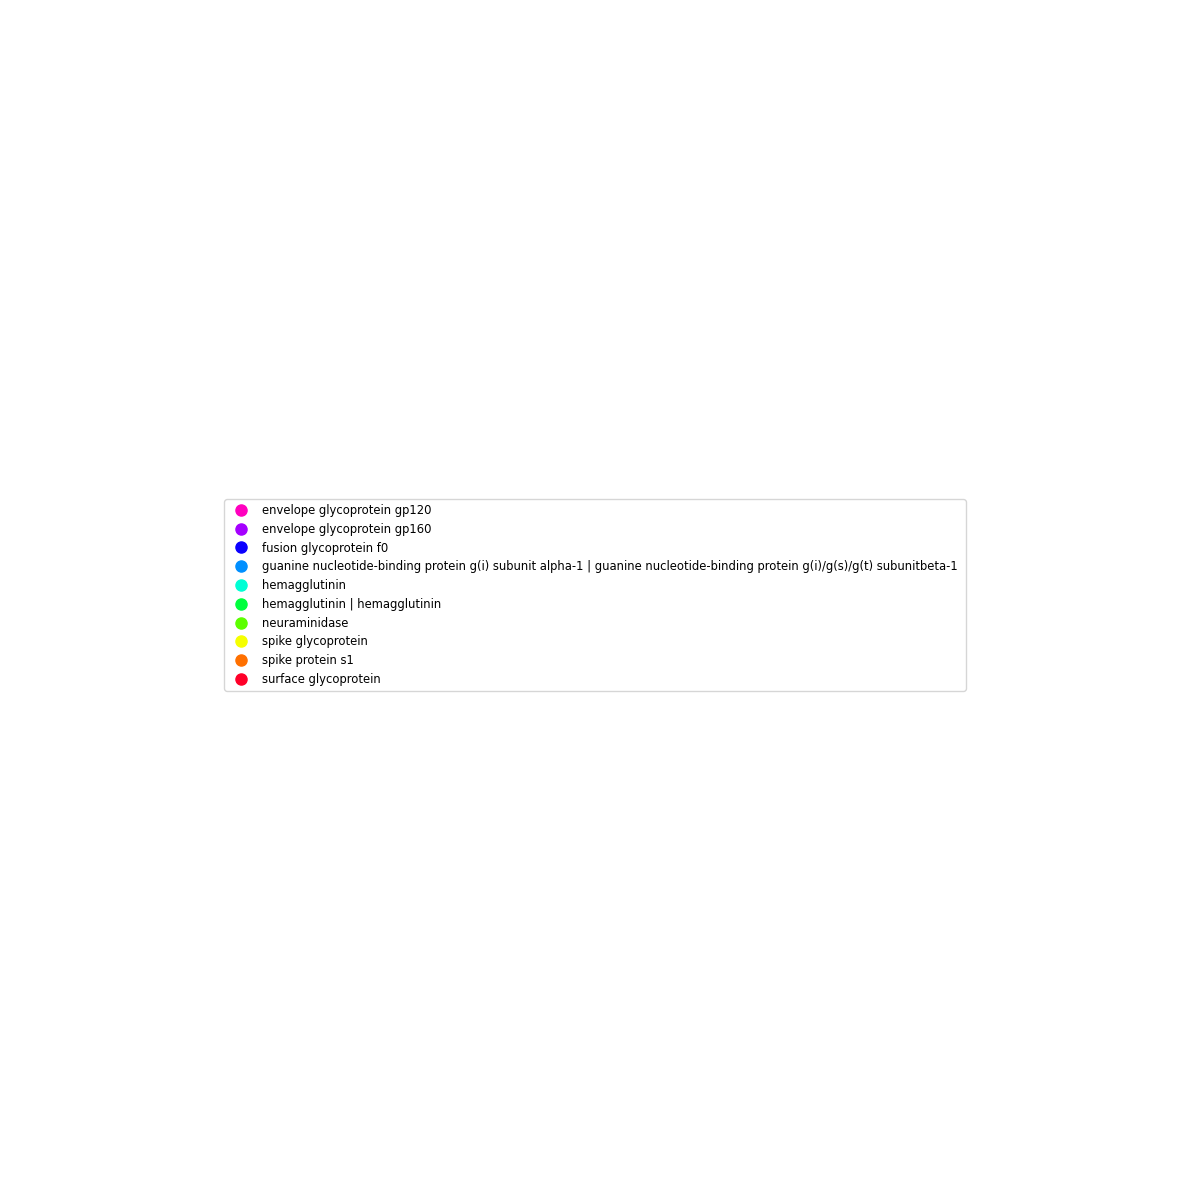

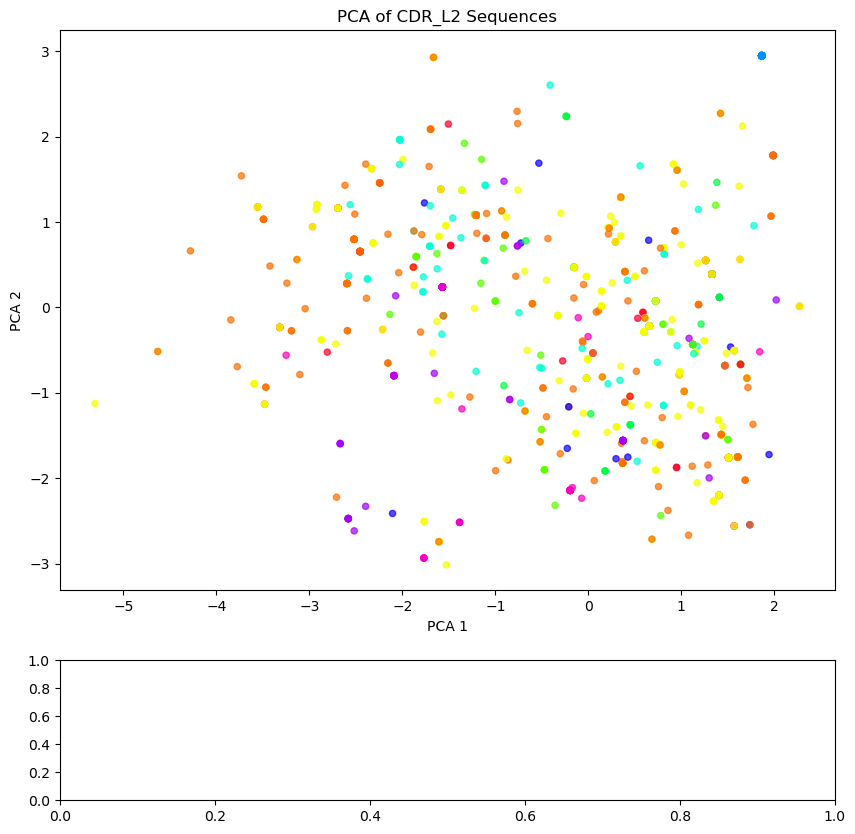

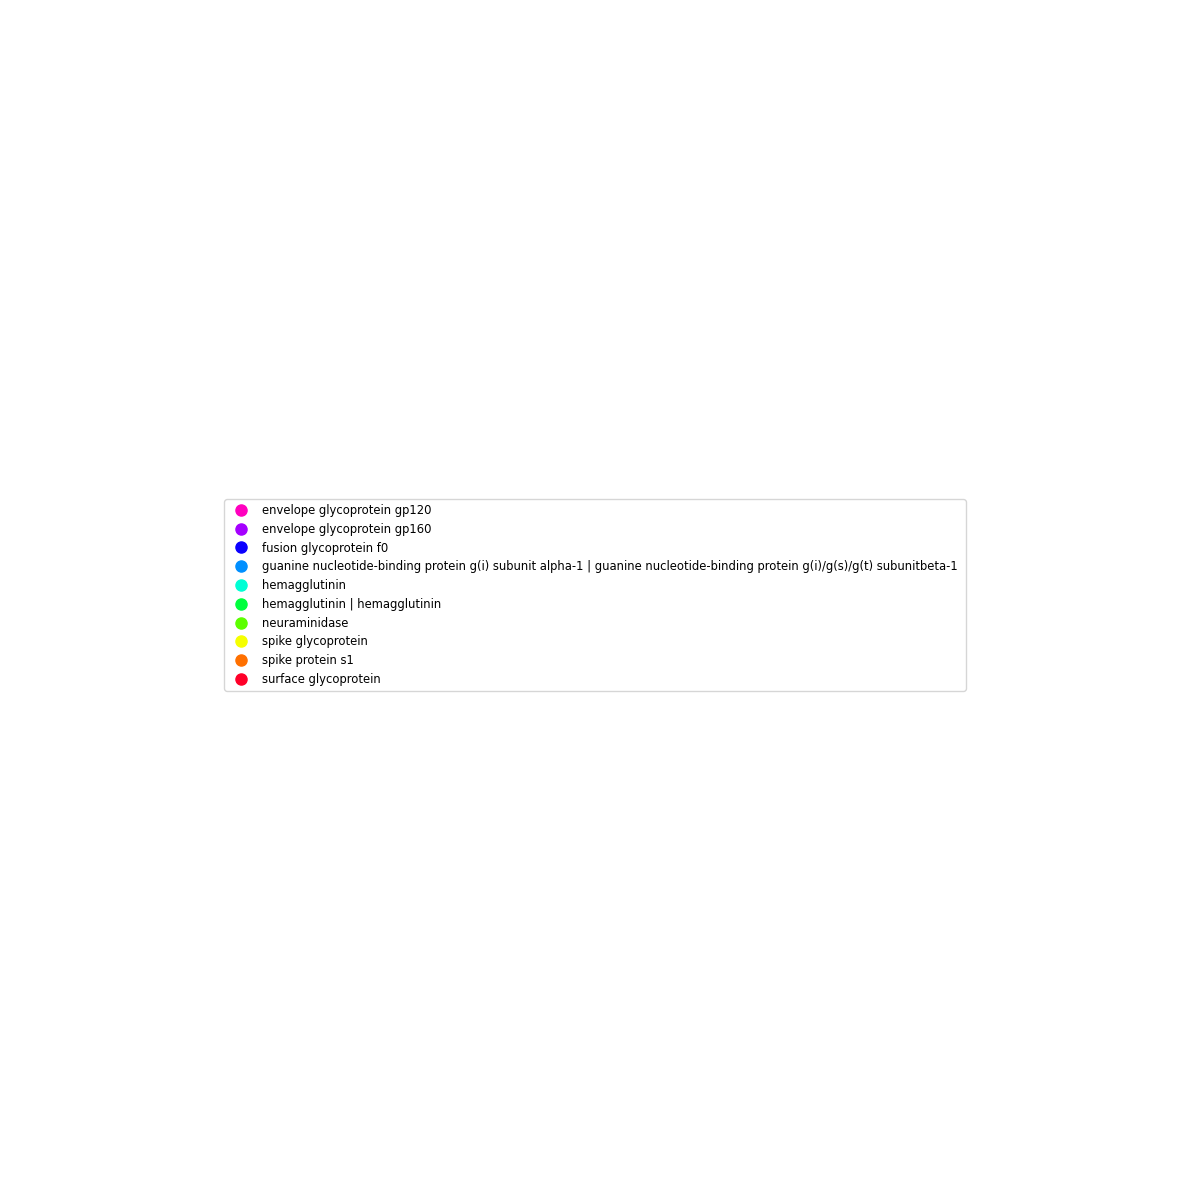

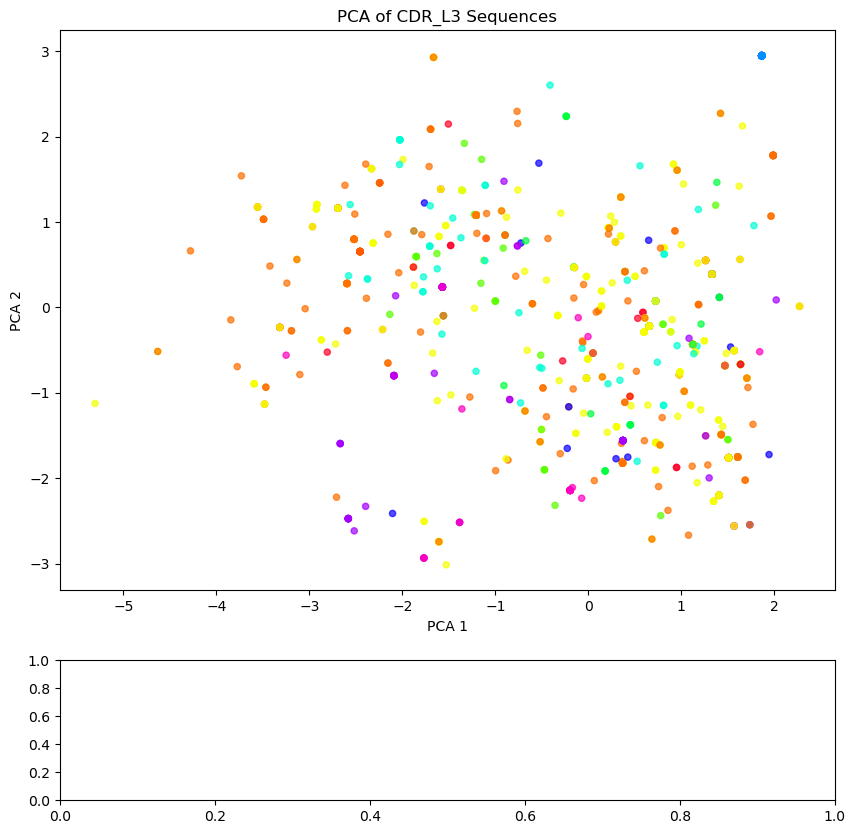

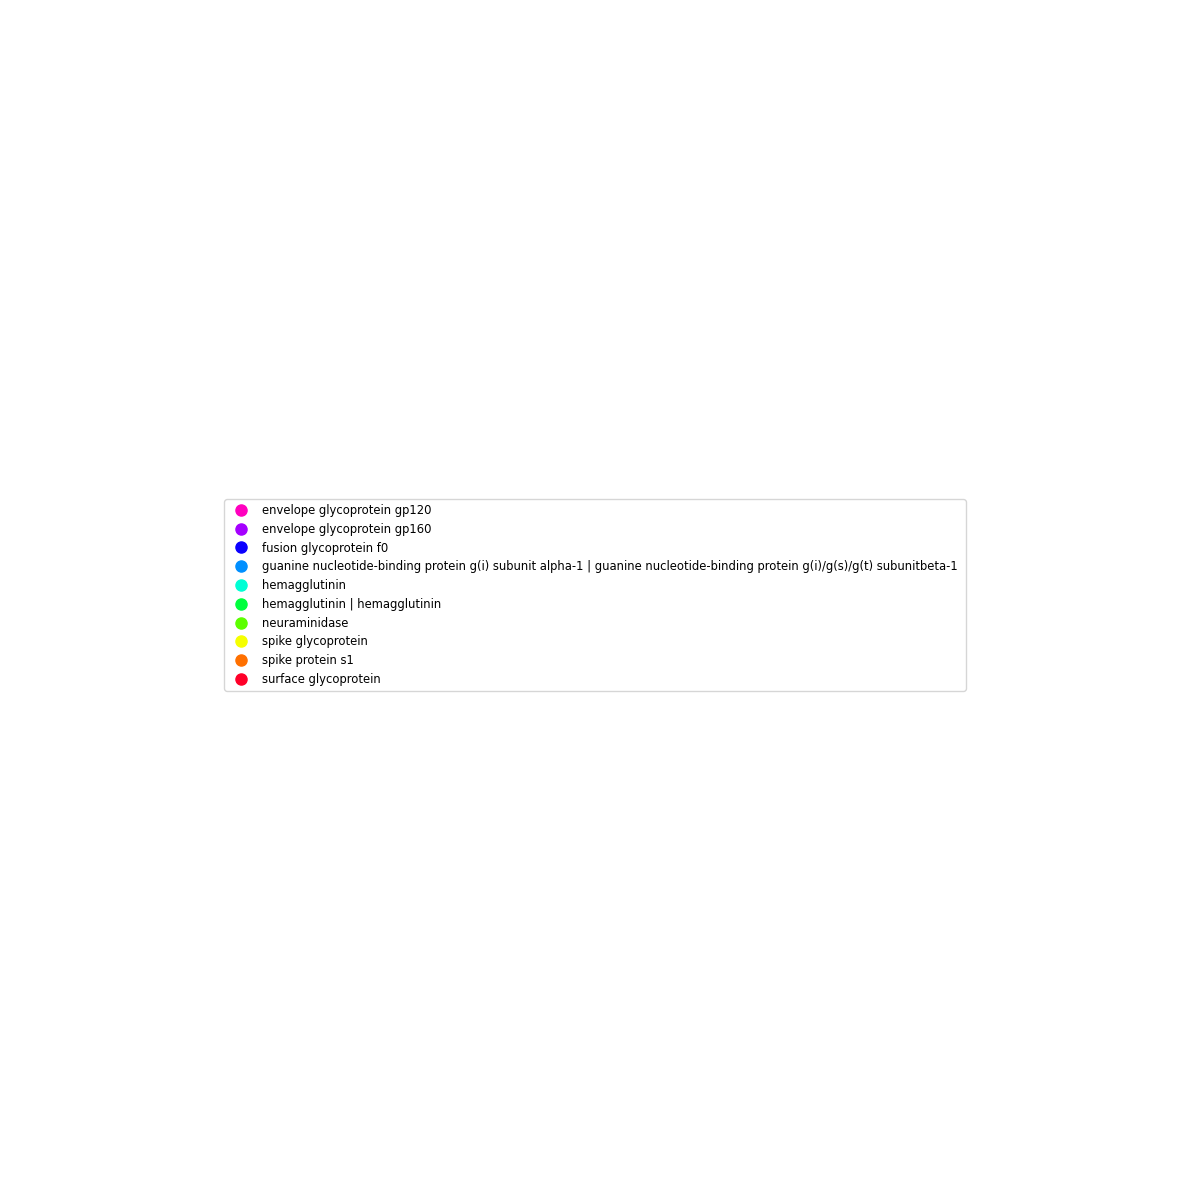

hemagglutinin: (0.0, 1.0, 0.836320191158901, 1.0)
spike glycoprotein: (0.9609609609609602, 1.0, 0.0, 1.0)
neuraminidase: (0.36036036036036045, 1.0, 0.0, 1.0)
spike protein s1: (1.0, 0.43843843843843866, 0.0, 1.0)
envelope glycoprotein gp160: (0.6461352657004832, 0.0, 1.0, 1.0)
hemagglutinin | hemagglutinin: (0.0, 1.0, 0.23894862604540001, 1.0)
surface glycoprotein: (1.0, 0.0, 0.16, 1.0)
fusion glycoprotein f0: (0.04227053140096615, 0.0, 1.0, 1.0)
envelope glycoprotein gp120: (1.0, 0.0, 0.75, 1.0)
guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : (0.0, 0.5615942028985507, 1.0, 1.0)


In [45]:

for region in regions: 
    feature_space = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"]) 
    show_feature_space(feature_space, region, antigen_labels)


#Überprüfung ob alle punkte mit gleichem antigen-name die gleiche farbe haben am bsp influenza a virus
idx_influenzaavirus = [i for i, a in enumerate(antigen_labels) if a == "influenza a virus"]
set([colors[i] for i in idx_influenzaavirus])

#alle farben pro antigen tabellarisch
for ant in set(antigen_labels):
    print(f"{ant}: {color_dict[ant]}")

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

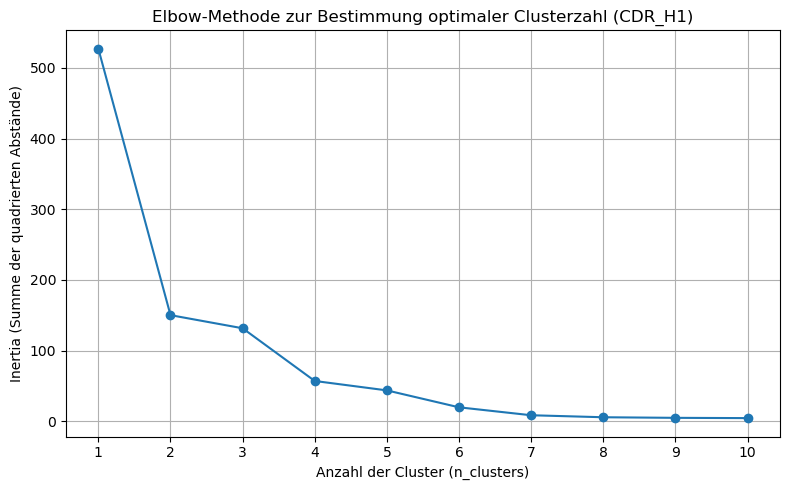

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

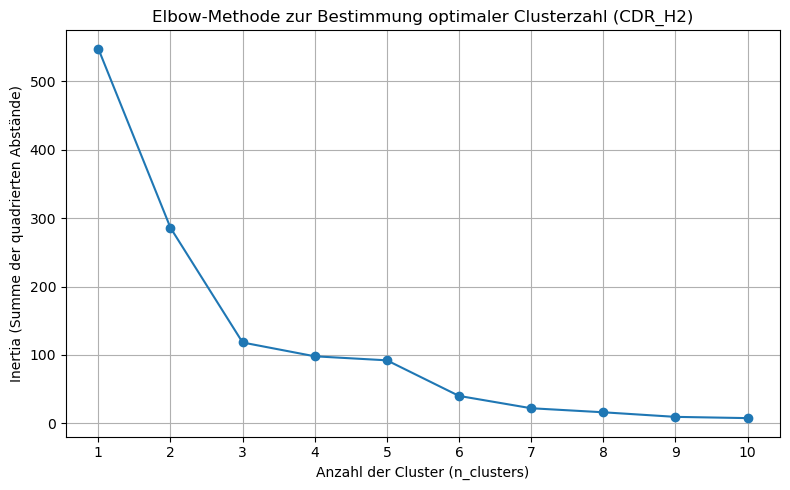

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

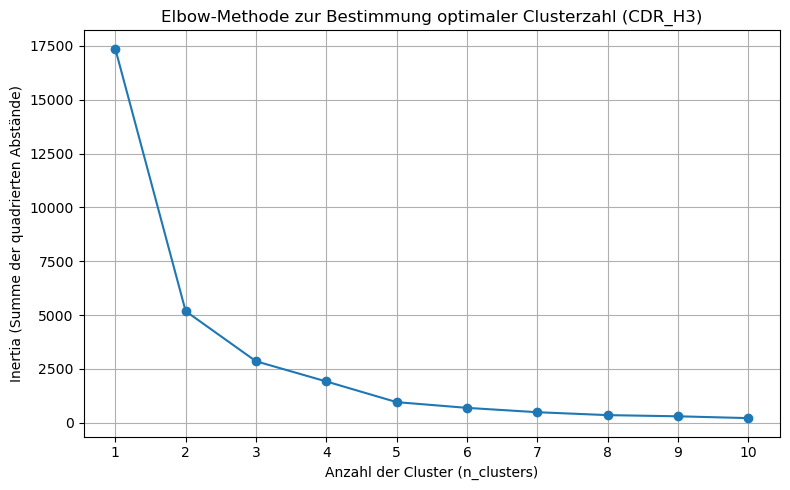

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

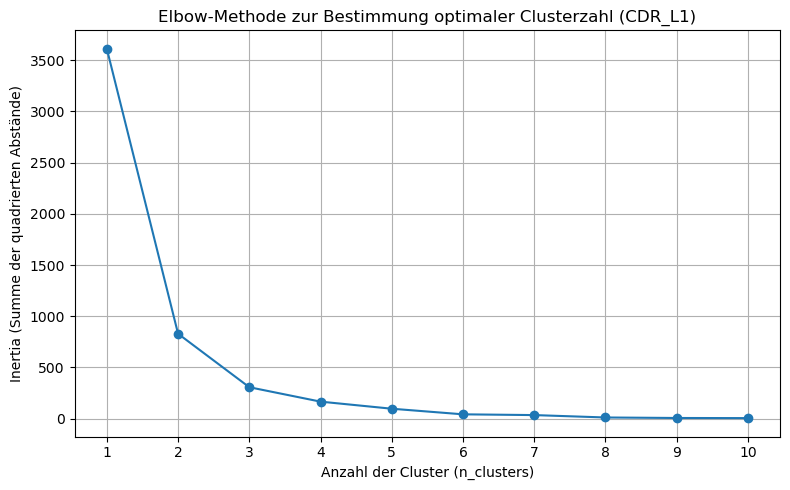

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

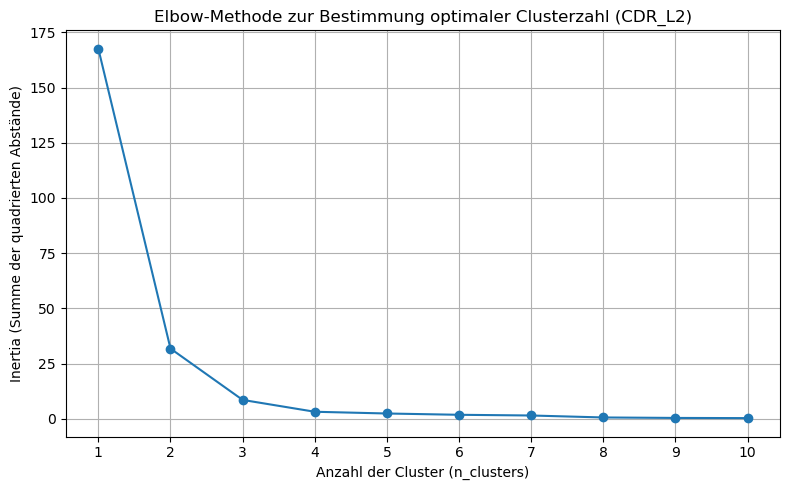

c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

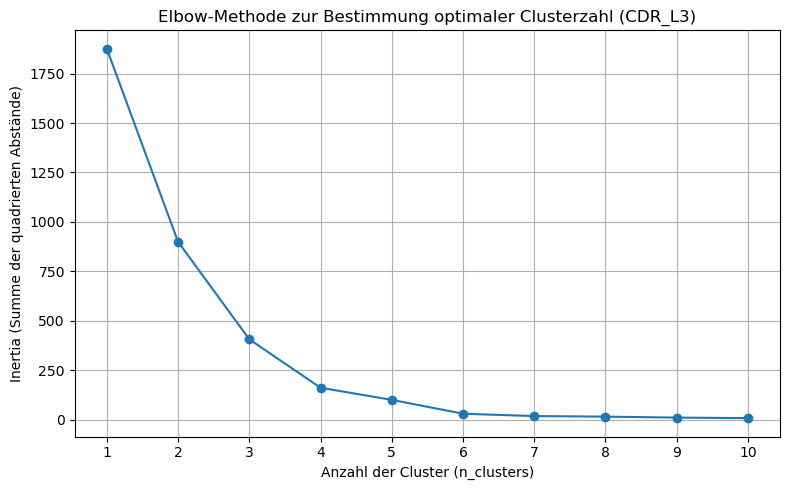

In [38]:
#elbow method 
#der erste teil ist wieder nur wdh weil der sonst die variabeln nicht findet

for region in regions:
    feature_space = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    #elbow method
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


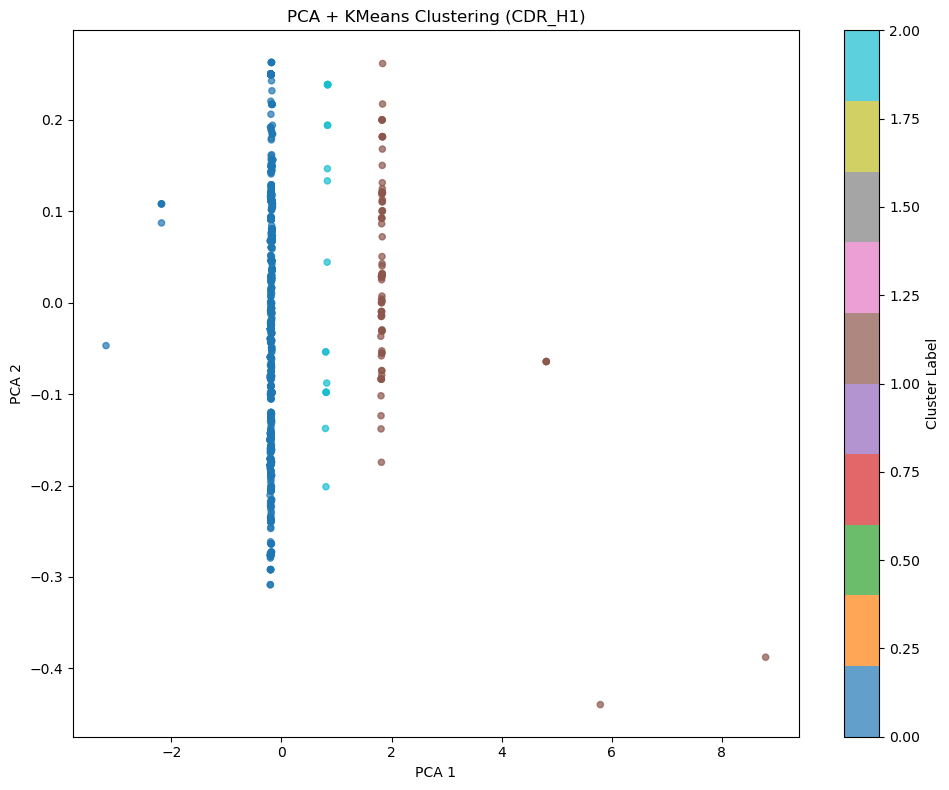


 Antigen Häufigkeiten pro Cluster für CDR_H1 

Cluster 0:
  spike glycoprotein: 317x
  spike protein s1: 293x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  envelope glycoprotein gp160: 51x
  envelope glycoprotein gp120: 38x
  hemagglutinin: 37x
  surface glycoprotein: 29x
  neuraminidase: 28x
  hemagglutinin | hemagglutinin: 24x
  fusion glycoprotein f0: 19x

Cluster 1:
  spike glycoprotein: 25x
  spike protein s1: 21x
  hemagglutinin: 20x
  neuraminidase: 6x
  surface glycoprotein: 4x
  fusion glycoprotein f0: 2x
  envelope glycoprotein gp120: 2x
  envelope glycoprotein gp160: 1x

Cluster 2:
  hemagglutinin: 7x
  spike glycoprotein: 5x
  spike protein s1: 4x
  neuraminidase: 1x
  envelope glycoprotein gp160: 1x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


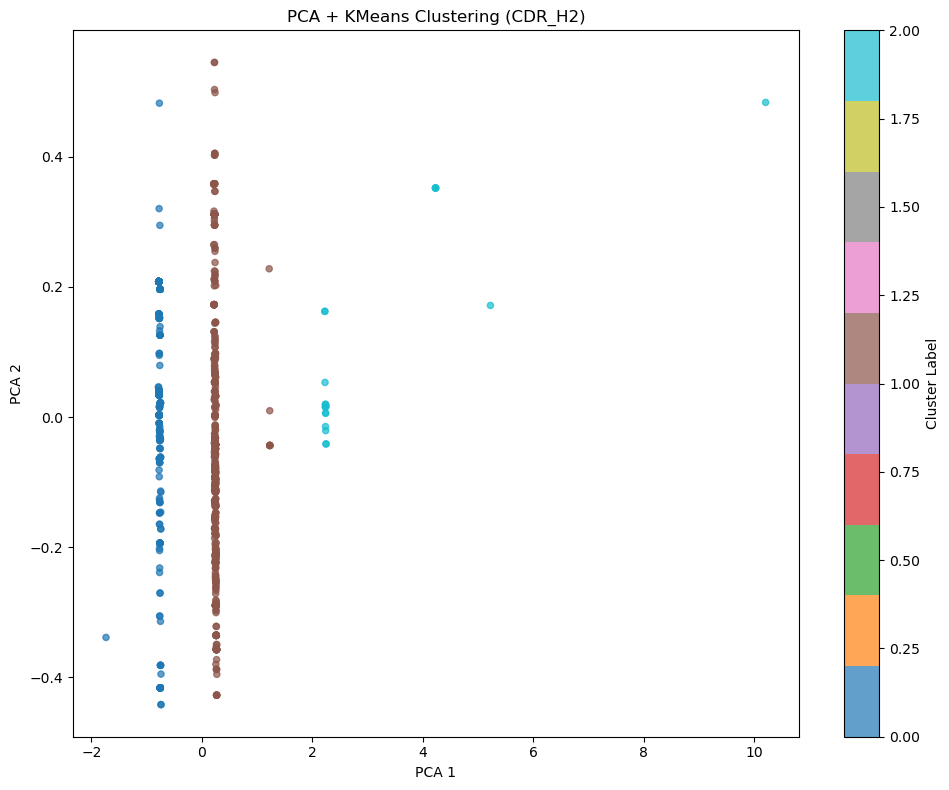


 Antigen Häufigkeiten pro Cluster für CDR_H2 

Cluster 0:
  spike protein s1: 125x
  spike glycoprotein: 88x
  hemagglutinin: 29x
  envelope glycoprotein gp160: 19x
  surface glycoprotein: 17x
  envelope glycoprotein gp120: 11x
  neuraminidase: 9x
  fusion glycoprotein f0: 5x
  hemagglutinin | hemagglutinin: 3x

Cluster 1:
  spike glycoprotein: 247x
  spike protein s1: 187x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 34x
  envelope glycoprotein gp160: 33x
  envelope glycoprotein gp120: 29x
  neuraminidase: 26x
  hemagglutinin | hemagglutinin: 21x
  fusion glycoprotein f0: 16x
  surface glycoprotein: 16x

Cluster 2:
  spike glycoprotein: 12x
  spike protein s1: 6x
  hemagglutinin: 1x
  envelope glycoprotein gp160: 1x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


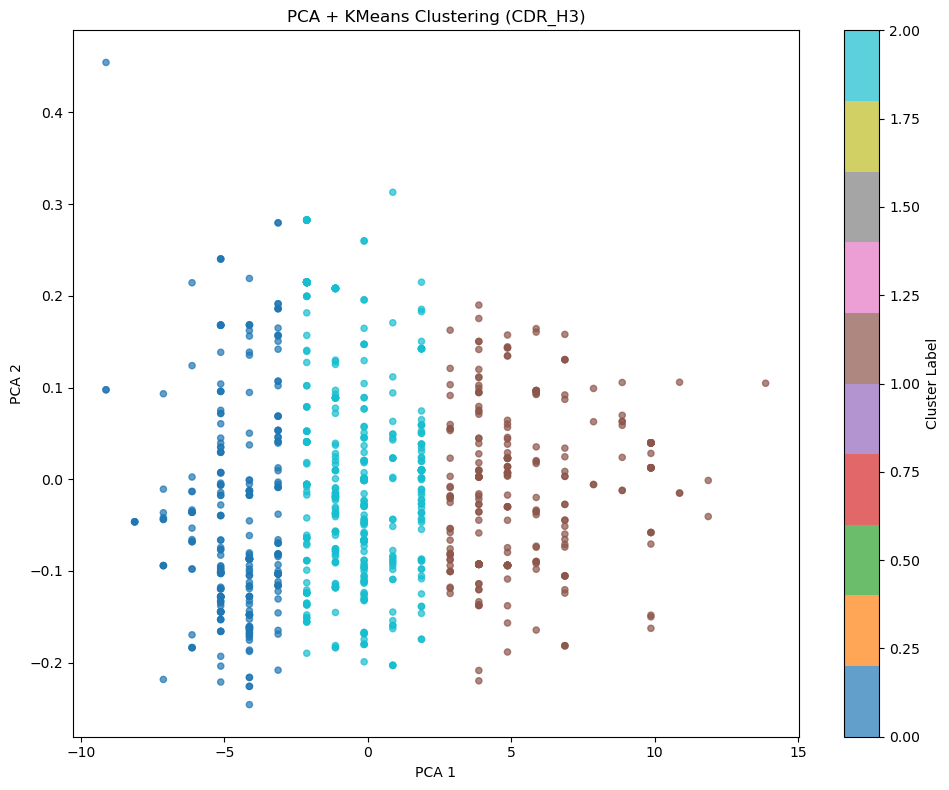


 Antigen Häufigkeiten pro Cluster für CDR_H3 

Cluster 0:
  spike protein s1: 135x
  spike glycoprotein: 115x
  surface glycoprotein: 8x
  hemagglutinin: 5x
  neuraminidase: 3x
  fusion glycoprotein f0: 3x
  envelope glycoprotein gp120: 2x
  envelope glycoprotein gp160: 2x
  hemagglutinin | hemagglutinin: 1x

Cluster 1:
  spike glycoprotein: 79x
  spike protein s1: 73x
  envelope glycoprotein gp120: 29x
  hemagglutinin: 28x
  neuraminidase: 26x
  envelope glycoprotein gp160: 25x
  hemagglutinin | hemagglutinin: 9x
  surface glycoprotein: 6x
  fusion glycoprotein f0: 3x

Cluster 2:
  spike glycoprotein: 153x
  spike protein s1: 110x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 31x
  envelope glycoprotein gp160: 26x
  surface glycoprotein: 19x
  fusion glycoprotein f0: 15x
  hemagglutinin | hemagglutinin: 14x
  envelope glycoprotein gp120: 9x
  neuraminidase: 6x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


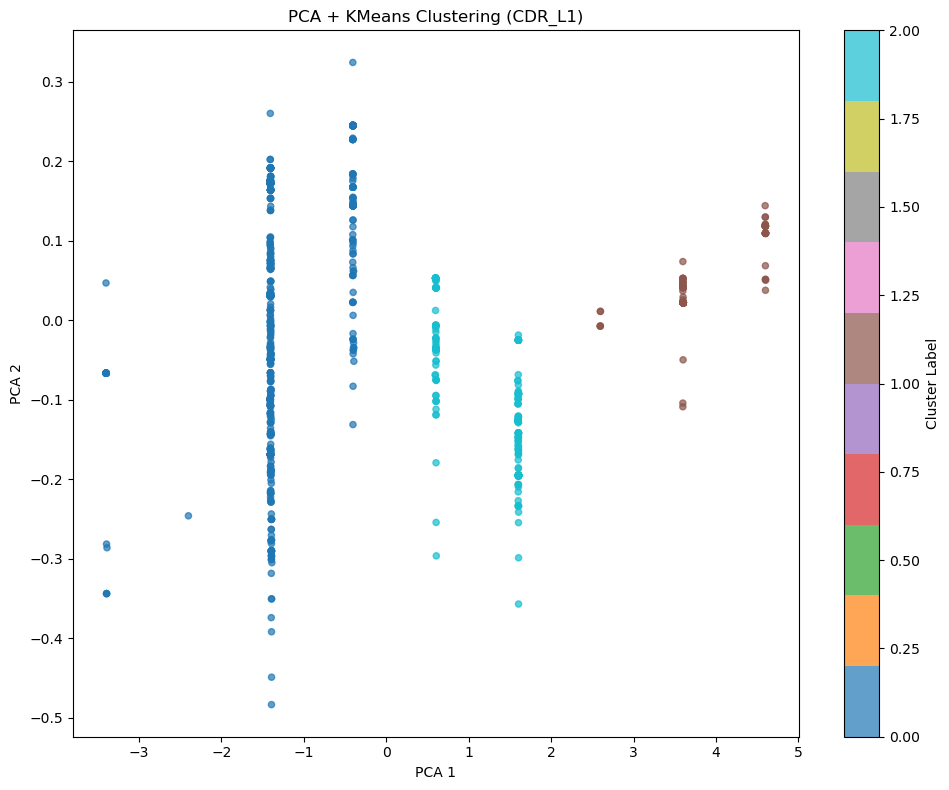


 Antigen Häufigkeiten pro Cluster für CDR_L1 

Cluster 0:
  spike glycoprotein: 239x
  spike protein s1: 221x
  hemagglutinin: 41x
  envelope glycoprotein gp160: 37x
  envelope glycoprotein gp120: 35x
  surface glycoprotein: 28x
  neuraminidase: 25x
  hemagglutinin | hemagglutinin: 16x
  fusion glycoprotein f0: 11x

Cluster 1:
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  spike glycoprotein: 29x
  spike protein s1: 22x
  hemagglutinin: 7x
  fusion glycoprotein f0: 2x
  surface glycoprotein: 2x
  neuraminidase: 1x

Cluster 2:
  spike glycoprotein: 79x
  spike protein s1: 75x
  hemagglutinin: 16x
  envelope glycoprotein gp160: 16x
  neuraminidase: 9x
  fusion glycoprotein f0: 8x
  hemagglutinin | hemagglutinin: 8x
  envelope glycoprotein gp120: 5x
  surface glycoprotein: 3x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


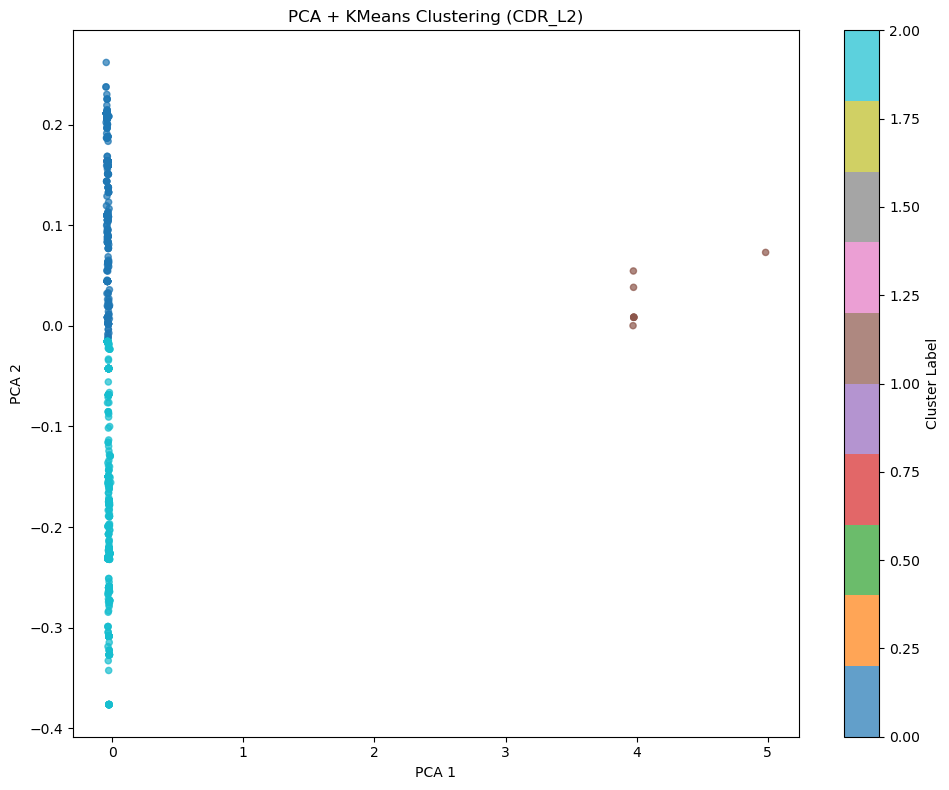


 Antigen Häufigkeiten pro Cluster für CDR_L2 

Cluster 0:
  spike glycoprotein: 203x
  spike protein s1: 200x
  hemagglutinin: 30x
  surface glycoprotein: 28x
  neuraminidase: 24x
  envelope glycoprotein gp120: 19x
  hemagglutinin | hemagglutinin: 16x
  envelope glycoprotein gp160: 16x
  fusion glycoprotein f0: 5x

Cluster 1:
  spike glycoprotein: 5x
  spike protein s1: 2x
  hemagglutinin: 1x

Cluster 2:
  spike glycoprotein: 139x
  spike protein s1: 116x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  envelope glycoprotein gp160: 37x
  hemagglutinin: 33x
  envelope glycoprotein gp120: 21x
  fusion glycoprotein f0: 16x
  neuraminidase: 11x
  hemagglutinin | hemagglutinin: 8x
  surface glycoprotein: 5x


c:\Users\marce\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


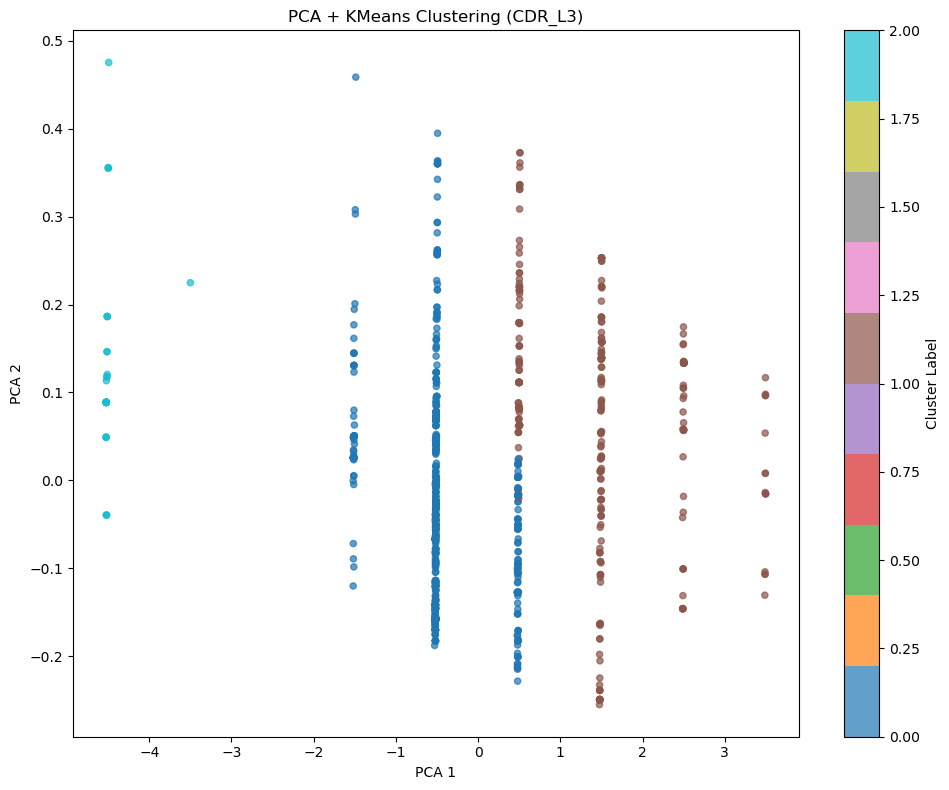


 Antigen Häufigkeiten pro Cluster für CDR_L3 

Cluster 0:
  spike glycoprotein: 245x
  spike protein s1: 227x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 42x
  neuraminidase: 26x
  surface glycoprotein: 26x
  hemagglutinin | hemagglutinin: 16x
  fusion glycoprotein f0: 11x
  envelope glycoprotein gp160: 5x
  envelope glycoprotein gp120: 2x

Cluster 1:
  spike glycoprotein: 97x
  spike protein s1: 89x
  envelope glycoprotein gp160: 34x
  envelope glycoprotein gp120: 27x
  hemagglutinin: 21x
  fusion glycoprotein f0: 10x
  neuraminidase: 9x
  hemagglutinin | hemagglutinin: 8x
  surface glycoprotein: 7x

Cluster 2:
  envelope glycoprotein gp160: 14x
  envelope glycoprotein gp120: 11x
  spike glycoprotein: 5x
  spike protein s1: 2x
  hemagglutinin: 1x


In [39]:
# Clustering auf basis der PCA
#kmeans mit 3 => laut elbow method am sinnvollsten

 # Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen:
for region in regions:
    feature_space = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=3, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")


In [40]:
#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären



 Kontingenztabelle für CDR_H1
Cluster                                               0   1   2
Antigen                                                        
envelope glycoprotein gp120                           2  27  11
envelope glycoprotein gp160                           5  34  14
fusion glycoprotein f0                               11  10   0
guanine nucleotide-binding protein g(i) subunit...   77   0   0
hemagglutinin                                        42  21   1
hemagglutinin | hemagglutinin                        16   8   0
neuraminidase                                        26   9   0
spike glycoprotein                                  245  97   5
spike protein s1                                    227  89   2
surface glycoprotein                                 26   7   0

 Chi-Quadrat-Test Ergebnis für CDR_H1
Chi2-Wert: 308.4700
p-Wert:    8.6998e-55
Freiheitsgrade: 18

Erwartete Häufigkeiten (unter Nullhypothese):
Cluster                                               